# **Exercise 1 : Only 1,2,3 to be submitted**

# Question 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    x1, x2 = x
    return x1**2 + 4*x1*x2 + 1600*x2**2

def grad_f(x):
    x1, x2 = x
    return np.array([2*x1 + 4*x2,
                    4*x1 + 3200*x2])

def hessian_f():
    return np.array([[2, 4],
                    [4, 3200]])

H = hessian_f()
eigvals = np.linalg.eigvals(H)
cond_H = np.linalg.cond(H)

print("Hessian:\n", H)
print("Eigenvalues:", eigvals)
print("Condition number of Hessian:", cond_H)


Hessian:
 [[   2    4]
 [   4 3200]]
Eigenvalues: [1.99499688e+00 3.20000500e+03]
Condition number of Hessian: 1604.0150407248495


# Question 2

The scaling matrix is defined as
$D = M M^T$, where $M \in \mathbb{R}^{n \times n}$ is an invertible matrix.

First, we verify that $D$ is symmetric. Taking the transpose,
$D^T = (M M^T)^T = M M^T = D$.
Hence, $D$ is symmetric.

Next, we show that $D$ is positive definite. For any non-zero vector $z$,
$z^T D z = z^T M M^T z = (M^T z)^T (M^T z) = |M^T z|^2$.
Since $M$ is invertible, $M^T z \neq 0$ whenever $z \neq 0$, and therefore
$|M^T z|^2 > 0$. This proves that $D$ is positive definite.

Thus, the scaling matrix $D$ is symmetric and positive definite.

In the standard gradient descent method, the convergence behavior depends on
the condition number of the Hessian matrix $\nabla^2 f(x)$. When scaling is
introduced, the update rule becomes
$x_{k+1} = x_k - \eta D \nabla f(x_k)$.

From the variable transformation and derivation, the effective matrix that
governs the convergence of the scaled gradient descent method is
$Q = D^{1/2} (\nabla^2 f(x)) D^{1/2}$.
Therefore, the condition number of the matrix $Q$ determines the convergence
rate of the gradient descent algorithm with scaling.

# Question 3


Training without scaling:                                                                    Training with scaling:
rho=  0.9 | x*=[-4.86897154e-13  5.56578299e-16] | f(x*)=2.36e-25 | iterations= 3583         rho=  0.9 | x*=[-4.39447021e-15  2.44139938e-16] | f(x*)=1.10e-28 | iterations=15
rho=  0.8 | x*=[-4.79006925e-13  5.77859847e-16] | f(x*)=2.29e-25 | iterations= 1331         rho=  0.8 | x*=[-9.76561279e-16  4.88265991e-18] | f(x*)=9.73e-31 | iterations=16
rho= 0.75 | x*=[-4.12345553e-13  4.98693146e-16] | f(x*)=1.70e-25 | iterations=  538         rho= 0.75 | x*=[-1.22070198e-15  4.57744598e-18] | f(x*)=1.50e-30 | iterations=16
rho=  0.6 | x*=[-4.86809153e-13  6.52330287e-16] | f(x*)=2.36e-25 | iterations= 5615         rho=  0.6 | x*=[-1.95312408e-15  3.66180420e-18] | f(x*)=3.81e-30 | iterations=16
rho=  0.5 | x*=[-4.77038750e-13  6.86254384e-16] | f(x*)=2.27e-25 | iterations=16981         rho=  0.5 | x*=[-1.22375412e-15  3.05156660e-18] | f(x*)=1.50e-30 | iterations=17
rho=  0.

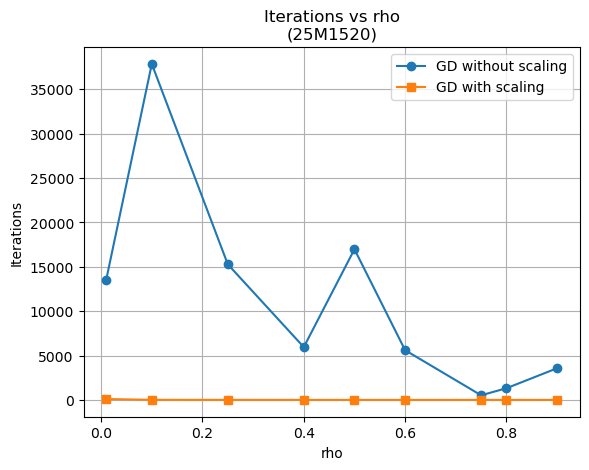

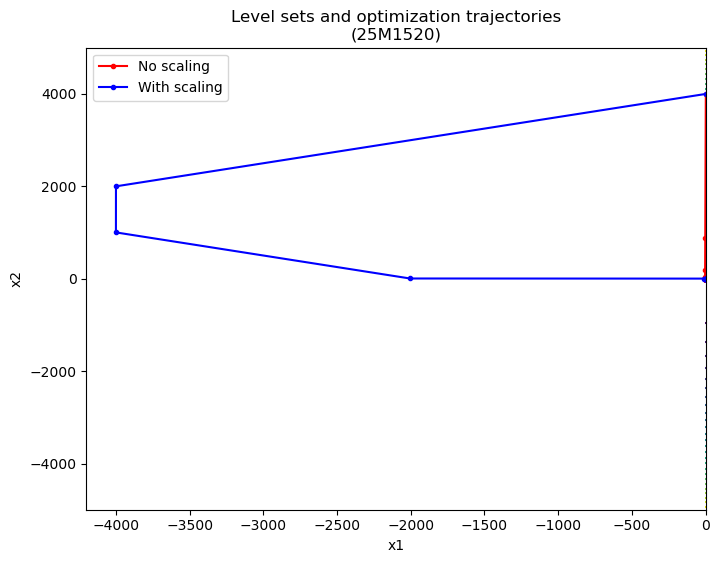

In [2]:
def backtracking_line_search(f, grad, x, p, alpha=1.0, rho=0.5, gamma=0.5):
    fx = f(x)
    gradx = grad(x)
    while f(x + alpha*p) > fx + gamma*alpha*np.dot(gradx, p):
        alpha *= rho
    return alpha

def gradient_descent(f, grad, x0, tol=1e-12, max_iter=100000,
                    scaled=False, D=None, rho=0.5):
    x = x0.copy()
    trajectory = [x.copy()]
    k = 0

    while np.linalg.norm(grad(x)) > tol and k < max_iter:
        if scaled:
            p = -D @ grad(x)
        else:
            p = -grad(x)

        alpha = backtracking_line_search(f, grad, x, p, rho=rho)
        x = x + alpha * p
        trajectory.append(x.copy())
        k += 1

    return x, f(x), k, np.array(trajectory)

x0 = np.array([1.0, 4000.0])
rho_values = [0.9, 0.8, 0.75, 0.6, 0.5, 0.4, 0.25, 0.1, 0.01]

D = np.diag(1 / np.diag(H))   # diagonal scaling

iters_no_scale = []
iters_scaled = []

results = {}

print("\nTraining without scaling:"+" "*68+"Training with scaling:")
for rho in rho_values:
    x1, fx1, k1, traj1 = gradient_descent(f, grad_f, x0, scaled=False, rho=rho)
    x2, fx2, k2, traj2 = gradient_descent(f, grad_f, x0, scaled=True, D=D, rho=rho)

    iters_no_scale.append(k1)
    iters_scaled.append(k2)

    results[rho] = (traj1, traj2)
    part1 = f"rho={rho:>5} | x*={x1} | f(x*)={fx1:.2e} | iterations={k1:>5}         "
    part2 = f"rho={rho:>5} | x*={x2} | f(x*)={fx2:.2e} | iterations={k2}"
    print(part1 + part2)

plt.figure()
plt.plot(rho_values, iters_no_scale, 'o-', label="GD without scaling")
plt.plot(rho_values, iters_scaled, 's-', label="GD with scaling")
plt.xlabel("rho")
plt.ylabel("Iterations")
plt.legend()
plt.title("Iterations vs rho\n(25M1520)")
plt.grid()
plt.show()

x1 = np.linspace(-5, 5, 400)
x2 = np.linspace(-5000, 5000, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = X1**2 + 4*X1*X2 + 1600*X2**2

rho_plot = 0.5
traj_ns, traj_s = results[rho_plot]

plt.figure(figsize=(8, 6))
plt.contour(X1, X2, Z, levels=30)
plt.plot(traj_ns[:,0], traj_ns[:,1], 'r.-', label="No scaling")
plt.plot(traj_s[:,0], traj_s[:,1], 'b.-', label="With scaling")
plt.legend()
plt.title("Level sets and optimization trajectories\n(25M1520)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Observations:

1. $f(x) = x_1^2 + 4x_1x_2 + 1600x_2^2$ is convex with elongated level sets (ill-conditioned).
2. All rho values converge to the same minimizer $x^* = (0,0)$ and $f(x^*) = 0$.
3. Without scaling: slow, zig-zag convergence; sensitive to rho.
4. With diagonal scaling: fast, smooth convergence; robust to rho choice.
5. Contour plots show scaled GD follows level sets efficiently, unscaled GD zig-zags.
Conclusion: Scaling greatly improves convergence speed and stability for ill-conditioned problems


# **Exercise 2 : Only 1,2,3 to be submitted**

# Question 1,2,3

Minimizer: [0. 0.]
Minimum value: 4.0
Unique minimizer? Yes
Global minimum? Yes, function is convex (sum of convex functions)
Local minima? Only one, at x*
Function convex? Yes, Hessian is diagonal with positive entries.

Gradient Descent:
Minimizer: [7.62525638e-10 7.62525638e-10]
Minimum: 4.0
Iterations: 32

Newton's Method (no backtracking):
Minimizer: [2. 2.]
Minimum: 5.656854249492381
Iterations: 1000

Newton's Method (with backtracking):
Minimizer: [0. 0.]
Minimum: 4.0
Iterations: 1


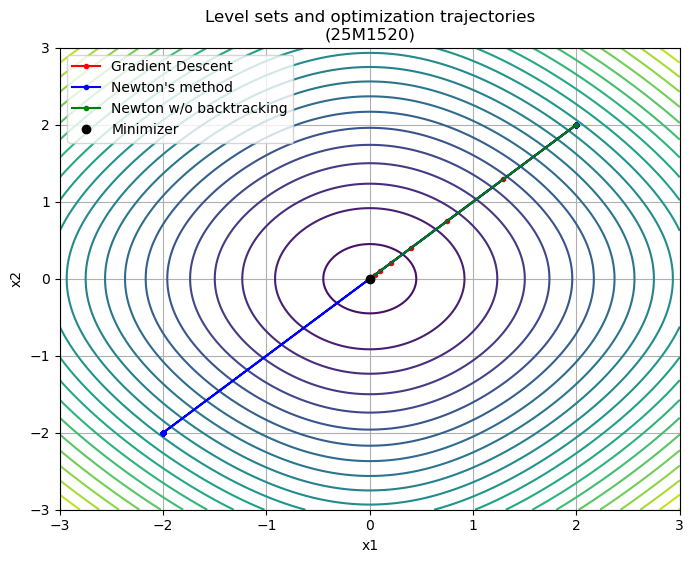

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def q(x):
    x1, x2 = x
    return np.sqrt(x1**2 + 4) + np.sqrt(x2**2 + 4)

def grad_q(x):
    x1, x2 = x
    return np.array([x1/np.sqrt(x1**2 + 4), x2/np.sqrt(x2**2 + 4)])

def hessian_q(x):
    x1, x2 = x
    H11 = 4 / (x1**2 + 4)**(3/2)
    H22 = 4 / (x2**2 + 4)**(3/2)
    return np.array([[H11, 0],
                     [0, H22]])

x_star = np.array([0.0, 0.0])
f_min = q(x_star)
print("Minimizer:", x_star)
print("Minimum value:", f_min)
print("Unique minimizer? Yes")
print("Global minimum? Yes, function is convex (sum of convex functions)")
print("Local minima? Only one, at x*")
print("Function convex? Yes, Hessian is diagonal with positive entries.")

def backtracking(f, grad, x, p, alpha=1.0, rho=0.5, gamma=0.5):
    fx = f(x)
    gx = grad(x)
    while f(x + alpha*p) > fx + gamma * alpha * np.dot(gx, p):
        alpha *= rho
    return alpha

def gradient_descent(f, grad, x0, tol=1e-9, max_iter=100000, rho=0.5):
    x = x0.copy()
    trajectory = [x.copy()]
    k = 0
    while np.linalg.norm(grad(x)) > tol and k < max_iter:
        p = -grad(x)
        alpha = backtracking(f, grad, x, p, rho=rho)
        x = x + alpha*p
        trajectory.append(x.copy())
        k += 1
    return x, f(x), k, np.array(trajectory)

def newton_method(f, grad, hess, x0, tol=1e-9, max_iter=1000, use_backtracking=False):
    x = x0.copy()
    trajectory = [x.copy()]
    k = 0
    while np.linalg.norm(grad(x)) > tol and k < max_iter:
        H = hess(x)
        g = grad(x)
        p = -np.linalg.solve(H, g)
        if use_backtracking:
            alpha = backtracking(f, grad, x, p)
        else:
            alpha = 1.0
        x = x + alpha * p
        trajectory.append(x.copy())
        k += 1
    return x, f(x), k, np.array(trajectory)

x0 = np.array([2.0, 2.0])

# Gradient Descent
x_gd, f_gd, k_gd, traj_gd = gradient_descent(q, grad_q, x0, rho=0.5)
print("\nGradient Descent:")
print("Minimizer:", x_gd)
print("Minimum:", f_gd)
print("Iterations:", k_gd)

# Newton's Method without backtracking
x_nm, f_nm, k_nm, traj_nm = newton_method(q, grad_q, hessian_q, x0, use_backtracking=False)
print("\nNewton's Method (no backtracking):")
print("Minimizer:", x_nm)
print("Minimum:", f_nm)
print("Iterations:", k_nm)

# Newton's Method with backtracking
x_nm_bt, f_nm_bt, k_nm_bt, traj_nm_bt = newton_method(q, grad_q, hessian_q, x0, use_backtracking=True)
print("\nNewton's Method (with backtracking):")
print("Minimizer:", x_nm_bt)
print("Minimum:", f_nm_bt)
print("Iterations:", k_nm_bt)

# Plot trajectories on level sets
x1_vals = np.linspace(-3, 3, 400)
x2_vals = np.linspace(-3, 3, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = np.sqrt(X1**2 + 4) + np.sqrt(X2**2 + 4)

plt.figure(figsize=(8,6))
plt.contour(X1, X2, Z, levels=30)
plt.plot(traj_gd[:,0], traj_gd[:,1], 'r.-', label="Gradient Descent")
plt.plot(traj_nm[:,0], traj_nm[:,1], 'b.-', label="Newton's method")
plt.plot(traj_nm_bt[:,0], traj_nm_bt[:,1], 'g.-', label="Newton w/o backtracking")
plt.plot(0,0,'ko', label="Minimizer")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Level sets and optimization trajectories\n(25M1520)")
plt.legend()
plt.grid(True)
plt.show()


# Observations:
1. Newton methods converge in very few iterations due to second-order information.
2. Gradient Descent requires more iterations, even with backtracking line search.
3. All methods converge to the same global minimizer and minimum value.
4. Trajectories: Gradient Descent is curved; Newton methods go almost straight to the minimum.



# **Exercise 3 : Only 1,2,3,4 to be submitted**

# Question 1

In [4]:
import numpy as np
import time

def f(x):
    return np.sum(4*(x[:-1]**2 - x[1:])**2 + (x[:-1] - 1)**2)

def grad_f(x):
    n = len(x)
    g = np.zeros(n)
    for i in range(n-1):
        g[i] += 16*x[i]*(x[i]**2 - x[i+1]) + 2*(x[i] - 1)
        g[i+1] += -8*(x[i]**2 - x[i+1])
    return g

def g_func(x):
    return np.sum((x[0] - x**2)**2 + (x - 1)**2)

def grad_g(x):
    n = len(x)
    grad = np.zeros(n)
    grad[0] = 2*np.sum(x[0] - x**2)
    for i in range(n):
        grad[i] += -4*x[i]*(x[0] - x[i]**2) + 2*(x[i] - 1)
    return grad

def backtracking(f, grad, x, p, alpha0=0.9, rho=0.5, c=0.5):
    alpha = alpha0
    fx = f(x)
    gx = grad(x)
    while f(x + alpha*p) > fx + c*alpha*np.dot(gx, p):
        alpha *= rho
    return alpha

def bfgs(f, grad, x0, tol=1e-6, max_iter=500):
    n = len(x0)
    x = x0.copy()
    B = np.eye(n)

    for _ in range(max_iter):
        gk = grad(x)
        if np.linalg.norm(gk) < tol:
            break

        pk = -B @ gk
        alpha = backtracking(f, grad, x, pk)
        x_new = x + alpha*pk

        sk = x_new - x
        yk = grad(x_new) - gk

        if np.dot(sk, yk) > 1e-10:
            Bs = B @ yk
            B += np.outer(sk, sk) / np.dot(sk, yk) \
                - np.outer(Bs, Bs) / np.dot(yk, Bs)

        x = x_new

    return x

def hessian_f(x):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n-1):
        H[i,i] += 48*x[i]**2 - 16*x[i+1] + 2
        H[i,i+1] += -16*x[i]
        H[i+1,i] += -16*x[i]
        H[i+1,i+1] += 8
    return H

def newton(f, grad, hess, x0, tol=1e-6, max_iter=50):
    x = x0.copy()
    for _ in range(max_iter):
        gk = grad(x)
        if np.linalg.norm(gk) < tol:
            break
        Hk = hess(x)
        pk = -np.linalg.solve(Hk, gk)
        alpha = backtracking(f, grad, x, pk)
        x = x + alpha*pk
    return x

print("Function f(x):")
print("Minimizer: x* = (1,1,...,1)")
print("Minimum value: f(x*) = 0")
print("Convexity: NOT convex")
print("Suitable B0 for BFGS: Identity matrix\n")

print("Function g(x):")
print("Minimizer: x* = (1,1,...,1)")
print("Minimum value: g(x*) = 0")
print("Convexity: NOT convex")
print("Suitable B0 for BFGS: Identity matrix\n")

ns = [1000, 2500, 5000]

Function f(x):
Minimizer: x* = (1,1,...,1)
Minimum value: f(x*) = 0
Convexity: NOT convex
Suitable B0 for BFGS: Identity matrix

Function g(x):
Minimizer: x* = (1,1,...,1)
Minimum value: g(x*) = 0
Convexity: NOT convex
Suitable B0 for BFGS: Identity matrix



# Question 2

In [5]:
print("\n\t  BFGS on f(x)")
for n in ns:
    x0 = np.zeros(n)
    start = time.time()
    x_star = bfgs(f, grad_f, x0)
    elapsed = time.time() - start
    print(f"n={n:5d} | f(x*)={f(x_star):.2e} | time={elapsed:.4f}s")


	  BFGS on f(x)
n= 1000 | f(x*)=4.48e-14 | time=2.6925s
n= 2500 | f(x*)=1.92e-14 | time=11.4989s
n= 5000 | f(x*)=1.05e-14 | time=38.5418s


# Question 3

In [6]:
print("\n\t  BFGS on g(x)")
for n in ns:
    x0 = np.zeros(n)
    start = time.time()
    x_star = bfgs(g_func, grad_g, x0)
    elapsed = time.time() - start
    print(f"n={n:5d} | g(x*)={g_func(x_star):.2e} | time={elapsed:.4f}s")


	  BFGS on g(x)
n= 1000 | g(x*)=3.23e-16 | time=0.3808s
n= 2500 | g(x*)=1.23e-16 | time=1.4455s
n= 5000 | g(x*)=5.75e-17 | time=4.4431s


# Question 4

In [7]:
print("\n\t  Newton on f(x)")
for n in ns:
    x0 = np.zeros(n)
    start = time.time()
    x_star = newton(f, grad_f, hessian_f, x0)
    elapsed = time.time() - start
    print(f"n={n:5d} | f(x*)={f(x_star):.2e} | time={elapsed:.4f}s")


	  Newton on f(x)
n= 1000 | f(x*)=5.78e+02 | time=1.8737s
n= 2500 | f(x*)=1.40e+03 | time=17.3187s
n= 5000 | f(x*)=2.76e+03 | time=114.6211s
